In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

In [ ]:
data= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/social_ads.csv")
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
scaler = StandardScaler()
x = scaler.fit_transform(data[['Age', 'EstimatedSalary']])

x= data[['Age','EstimatedSalary']].values
y = data['Purchased'].values

M = len(y)
x= np.hstack((x,np.ones([x.shape[0],1], x.dtype)))
print(np.shape(x))
print(np.shape(y))

(400, 3)
(400,)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [ ]:
theta_0 = np.zeros(3)
print(theta_0)

[0. 0. 0.]


In [ ]:
cost_history = [] # Use this array to log costs calculated in the call to scipy's "minimize" below.
def cost_function(theta, X, y, M):
    """Python version of costFunction.m."""
    #costfunction for logistic regression
    h_matrix=1/(1+np.exp(-np.dot(X,theta)))
    cost=(-1/M)*(np.sum(y*np.log(h_matrix)+(1-y)*(np.log(1-h_matrix))))
    grad=(1/M)*np.dot(X.T,(h_matrix-y))
    global cost_history
    cost_history.append(cost)
    return cost, grad

In [ ]:
cost_0, grad_0 = cost_function(theta_0, x, y, M)

print('Cost at initial theta (zeros):', cost_0)
print('Gradient at initial theta (zeros):', grad_0)

Cost at initial theta (zeros): 0.6931471805599452
Gradient at initial theta (zeros): [2.24250e+00 4.02875e+03 1.42500e-01]


In [ ]:
res = minimize(cost_function, theta_0, method='Newton-CG', args=(x_train, y_train, M), jac=True)
print(res)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 0.5510917878534336
       x: [-1.618e-09 -2.375e-06 -9.236e-11]
     nit: 1
     jac: [ 1.971e+00  2.892e+03  1.125e-01]
    nfev: 3
    njev: 4
    nhev: 0


In [ ]:
theta = res['x']

print('Cost at best-fit theta:', res['fun'])
print('Best-fit theta:', theta)

Cost at best-fit theta: 0.5510917878534336
Best-fit theta: [-1.61836382e-09 -2.37469491e-06 -9.23606492e-11]


(0.0, 2.3903840247431227)

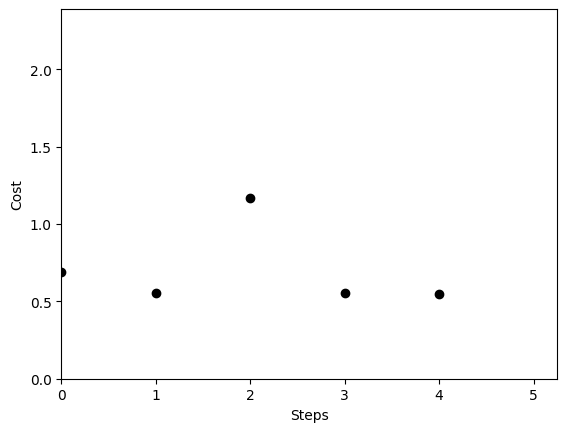

In [ ]:
plt.figure()
plt.scatter(np.arange(len(cost_history)), cost_history, c='k', marker='o')
plt.xlabel('Steps')
plt.ylabel('Cost')
plt.xlim(0, len(cost_history) * 1.05)
plt.ylim(0, max(cost_history) * 2.05)
# plt.savefig('ex2a_plots/cost_vs_steps.png', dpi=300)

In [ ]:
num_pts = 100
x_pts, y_pts = np.meshgrid(np.linspace(min(data['Age']),max(data['Age']), num_pts), np.linspace(min(data['EstimatedSalary']), max(data['EstimatedSalary']), num_pts) )
z= theta[2] + theta[1]*x_pts + theta[0]*y_pts
z= z.reshape(x_pts.shape)

plt.figure()
sns.reset_orig()
plt.plot(data['Age'][y == 0], data['EstimatedSalary'][y == 0], 'yo', ms=8, label='Not purchased')
plt.plot(data['Age'][y == 1], data['EstimatedSalary'][y == 1], 'k+', ms=8, label='purchased')
plt.contour(x_train, y_train, z, levels=[0], colors=['red'], linewidths=2)

# sns_reset()
plt.xlabel('Ages')
plt.ylabel('Salaries')
print("Exam 1 range:", min(data['Age']), max(data['Age']))
print("Exam 2 range:", min(data['EstimatedSalary']), max(data['EstimatedSalary']))
print("Theta values:", theta)
print("Min z:", np.min(z))
print("Max z:", np.max(z))

plt.xlim(min(data['Age'])-3, max(data['Age'])+1)
plt.ylim(min(data['EstimatedSalary'])-10000, max(data['EstimatedSalary'])+10000)
plt.legend(numpoints=1, loc=1)
# plt.savefig('ex2a_plots/fig2.png', dpi=300)

IndentationError: unexpected indent (<ipython-input-4-59315f63c1df>, line 4)

In [ ]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))

In [ ]:
def prediction(theta, exam_1, exam_2):
    """Python version of predict.m."""
    return sigmoid(theta[0] + exam_1 * theta[1] + exam_2 * theta[2])

def accuracy(theta, exam_1, exam_2, y, M):
    return np.sum(np.around(prediction(theta, exam_1, exam_2)) == y) / M

In [ ]:
result=prediction(theta,85,98500)
print('For a person with age 45 and salary 85000, we predict an purchasing probability of', result)

For a person with age 45 and salary 85000, we predict an purchasing probability of 0.4999406174905978


In [ ]:
text_file_path="/content/drive/MyDrive/Colab Notebooks/ex2data2.txt"

delimiter = ','  # Change this to your desired delimiter

import numpy as np

delimiter = ','  # Change to your delimiter
data2 = np.loadtxt(text_file_path, delimiter=delimiter) # Convert to integer after loading

print(np.shape(data2))

(118, 3)


In [ ]:
test_1 = data2[:, 0]
test_2 = data2[:, 1]

M = len(test_1)
y = data2[:, 2].astype(int)
print("y == 0 count:", np.sum(y == 0))
print("y == 1 count:", np.sum(y == 1))
print(test_2)

y == 0 count: 60
y == 1 count: 58
[ 0.69956   0.68494   0.69225   0.50219   0.46564   0.2098    0.034357
 -0.19225  -0.40424  -0.51389  -0.56506  -0.5212   -0.24342  -0.18494
  0.48757   0.5826    0.53874   0.81652   0.69956   0.63377   0.59722
  0.33406   0.005117 -0.27266  -0.39693  -0.60161  -0.53582  -0.53582
  0.54605   0.77997   0.96272   0.8019    0.64839   0.47295   0.31213
  0.027047 -0.21418  -0.18494  -0.16301  -0.41155  -0.2288   -0.18494
 -0.14108   0.012427  0.15863   0.26827   0.44371   0.52412   0.67032
  0.69225   0.57529   0.39985   0.55336   0.35599   0.17325   0.21711
 -0.016813 -0.27266   0.93348   0.77997   0.61915   0.75804   0.7288
  0.59722   0.50219   0.3633    0.27558   0.085526  0.012427 -0.082602
 -0.20687  -0.36769  -0.5212   -0.55775  -0.7405   -0.5943   -0.41886
 -0.57968  -0.76974  -0.75512  -0.57968  -0.4481   -0.41155  -0.25804
 -0.25804   0.041667  0.2902    0.68494   0.70687   0.91886   0.90424
  0.70687   0.77997   0.91886   0.99196   1.1089    1.0

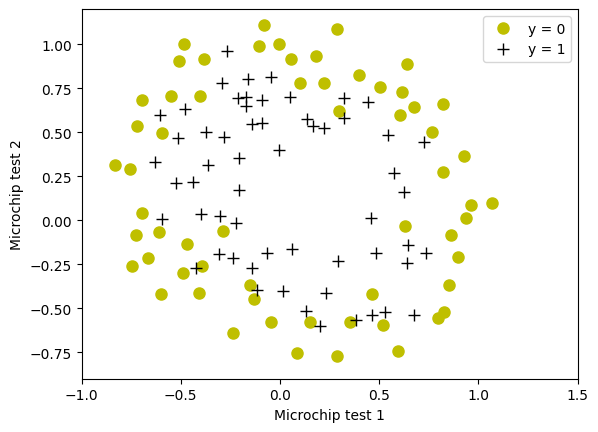

In [ ]:
plt.figure()
plt.plot(test_1[y == 0], test_2[y == 0], 'yo', ms=8, label='y = 0')
plt.plot(test_1[y == 1], test_2[y == 1], 'k+', ms=8, label='y = 1')
plt.xlabel('Microchip test 1')
plt.ylabel('Microchip test 2')
plt.xlim(-1, 1.5)
plt.ylim(-0.9, 1.2)
plt.legend(numpoints=1, loc=1)
# plt.savefig('ex2b_reg_plots/fig_1.png', dpi=300)

In [ ]:
max_degree = 6

def map_feature(test_1, test_2, M):
    """Python version of mapFeature.m."""
    # Add a column of ones to the data matrix that allows us to treat the intercept parameter as a feature.
    X_T = np.ones(M)

    for i in range(1, max_degree+1):
        for j in range(i+1):
            X_T = np.vstack((X_T, test_1**(i-j) * test_2**j))

    return X_T.T

In [ ]:
X = map_feature(test_1, test_2, M)
N = X.shape[1]
print(N)

28


In [ ]:
lam=1
theta_0 = np.zeros(N)
"""Python version of sigmoid.m."""
sigmoid = lambda x: 1 / (1 + np.exp(-x))

In [ ]:
cost_history = [] # Use this array to log costs calculated in the call to scipy's "minimize" below.

def cost_function(theta, X, y, M, lam):
    """Python version of costFunctionReg.m."""
    global cost_history
#to be completed by student
    h_matrix=sigmoid(np.dot(X,theta))
    cost = 1/M*(-np.sum(y.T*np.log(h_matrix)+(1-y).T*np.log(1-h_matrix))+(lam/(2*M))*np.sum(np.square(theta[1:])))
    grad = 1 / M * (sigmoid(theta.dot(X.T)) - y).dot(X) \
        + lam / M * np.array([0 if i == 0 else theta[i] for i in range(len(theta))])

    cost_history.append(cost)
    return cost, grad

In [ ]:
cost_0, _ = cost_function(theta_0, X, y, M, lam)

print('Cost at initial theta (zeros):', cost_0)

Cost at initial theta (zeros): 0.6931471805599454


In [ ]:
cost_history = []

"""This call to scipy's "minimize" is a Python version of the Octave call to "fminunc"."""
res = minimize(cost_function, theta_0, method='L-BFGS-B', args=(X, y, M, lam), jac=True)
print(res)

  message: ABNORMAL_TERMINATION_IN_LNSRCH
  success: False
   status: 2
      fun: 0.4616488538520947
        x: [ 1.260e+00  6.486e-01 ... -1.549e-01 -1.006e+00]
      nit: 7
      jac: [-1.577e-03  7.298e-04 ... -1.012e-04 -1.241e-03]
     nfev: 45
     njev: 45
 hess_inv: <28x28 LbfgsInvHessProduct with dtype=float64>


In [ ]:
theta = res['x']

print('Cost at best-fit theta:', res['fun'])

Cost at best-fit theta: 0.4616488538520947


In [ ]:
def plot_cost_vs_steps(cost_history, file_name_suffix=''):
    num_steps = len(cost_history)

    plt.figure()
    plt.scatter(np.arange(num_steps), cost_history, c='k', marker='o')
    plt.xlabel('Steps')
    plt.ylabel('Cost')
    plt.xlim(-num_steps * 0.05, num_steps * 1.05)
    plt.ylim(0, max(cost_history) * 1.05)
    # plt.savefig('ex2b_reg_plots/cost_vs_steps' + file_name_suffix + '.png', dpi=300)
    plot_cost_vs_steps(cost_history)

In [ ]:
def poly(theta, x_pts, y_pts):
    result = theta[0] + theta[1] * x_pts + theta[2] * y_pts - 0.5
    k = 3
    for i in range(2, max_degree+1):
        for j in range(i+1):
            result += theta[k] * x_pts**(i-j) * y_pts**j
            k += 1
    return result

In [ ]:
def plot_decision_boundary(test_1, test_2, theta, X, y, num_pts=100, file_name_suffix=''):
    """Python version of plotDecisionBoundary.m."""
    x_pts, y_pts = np.ogrid[min(test_1):max(test_1):num_pts * 1j, min(test_2):max(test_2):num_pts * 1j]

    plt.figure()
    sns.reset_orig()
    plt.plot(test_1[y == 0], test_2[y == 0], 'yo', ms=8, label='y = 0')
    plt.plot(test_1[y == 1], test_2[y == 1], 'k+', ms=8, label='y = 1')
    plt.contour(x_pts.ravel(), y_pts.ravel(), poly(theta, x_pts, y_pts), levels=[0])
    # sns_reset()
    plt.xlabel('Microchip test 1')
    plt.ylabel('Microchip test 2')
    plt.xlim(-1, 1.5)
    plt.ylim(-0.9, 1.2)
    plt.legend(numpoints=1, loc=1)
    # plt.savefig('ex2b_reg_plots/fig_2' + file_name_suffix + '.png', dpi=300)

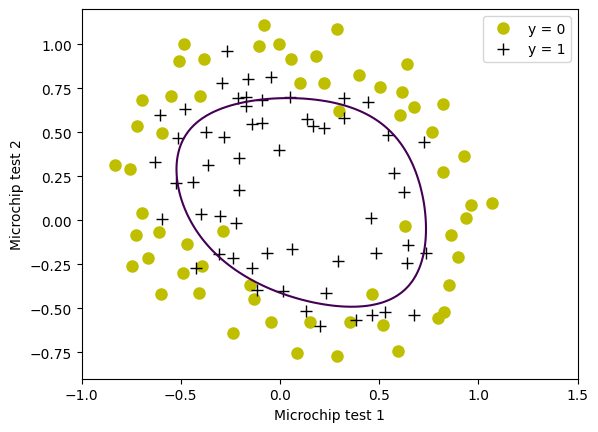

In [ ]:
plot_decision_boundary(test_1, test_2, theta, X, y)

In [ ]:
def prediction(theta, test_1, test_2):
    """Python version of predict.m."""
    return sigmoid(poly(theta, test_1, test_2))

def accuracy(theta, test_1, test_2, y, M):
    return np.sum(np.around(prediction(theta, test_1, test_2)) == y) / M

In [ ]:
print('For a microchip with test 1 and 2 scores of 0 and 0, we predict y = 1 with a probability of',prediction(theta, 0, 0))

For a microchip with test 1 and 2 scores of 0 and 0, we predict y = 1 with a probability of 0.6813556100824048


In [ ]:
print('Train Accuracy:', accuracy(theta, test_1, test_2, y, M))

Train Accuracy: 0.7796610169491526


In [ ]:
lam=0
theta_0 = np.zeros(N)
"""Python version of sigmoid.m."""
sigmoid = lambda x: 1 / (1 + np.exp(-x))

In [ ]:
cost_history = [] # Use this array to log costs calculated in the call to scipy's "minimize" below.

def cost_function(theta, X, y, M, lam):
    """Python version of costFunctionReg.m."""
    global cost_history
#to be completed by student
    h_matrix=sigmoid(np.dot(X,theta))
    cost = 1/M*(-np.sum(y.T*np.log(h_matrix)+(1-y).T*np.log(1-h_matrix))+(lam/(2*M))*np.sum(np.square(theta[1:])))
    grad = 1 / M * (sigmoid(theta.dot(X.T)) - y).dot(X) \
        + lam / M * np.array([0 if i == 0 else theta[i] for i in range(len(theta))])

    cost_history.append(cost)
    return cost, grad

In [ ]:
cost_0, _ = cost_function(theta_0, X, y, M, lam)

print('Cost at initial theta (zeros):', cost_0)

Cost at initial theta (zeros): 0.6931471805599454


In [ ]:
cost_history = []

"""This call to scipy's "minimize" is a Python version of the Octave call to "fminunc"."""
res = minimize(cost_function, theta_0, method='L-BFGS-B', args=(X, y, M, lam), jac=True)
print(res)

  message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
  success: True
   status: 0
      fun: 0.21954836668085556
        x: [ 3.973e+01  5.662e+01 ... -1.964e+03 -7.210e+02]
      nit: 3942
      jac: [-3.202e-06 -2.632e-06 ... -1.289e-06  4.569e-06]
     nfev: 4291
     njev: 4291
 hess_inv: <28x28 LbfgsInvHessProduct with dtype=float64>


In [ ]:
theta = res['x']

print('Cost at best-fit theta:', res['fun'])

Cost at best-fit theta: 0.21954836668085556


In [ ]:
def plot_cost_vs_steps(cost_history, file_name_suffix=''):
    num_steps = len(cost_history)

    plt.figure()
    plt.scatter(np.arange(num_steps), cost_history, c='k', marker='o')
    plt.xlabel('Steps')
    plt.ylabel('Cost')
    plt.xlim(-num_steps * 0.05, num_steps * 1.05)
    plt.ylim(0, max(cost_history) * 1.05)
    # plt.savefig('ex2b_reg_plots/cost_vs_steps' + file_name_suffix + '.png', dpi=300)
    plot_cost_vs_steps(cost_history)

In [ ]:
def poly(theta, x_pts, y_pts):
    result = theta[0] + theta[1] * x_pts + theta[2] * y_pts - 0.5
    k = 3
    for i in range(2, max_degree+1):
        for j in range(i+1):
            result += theta[k] * x_pts**(i-j) * y_pts**j
            k += 1
    return result

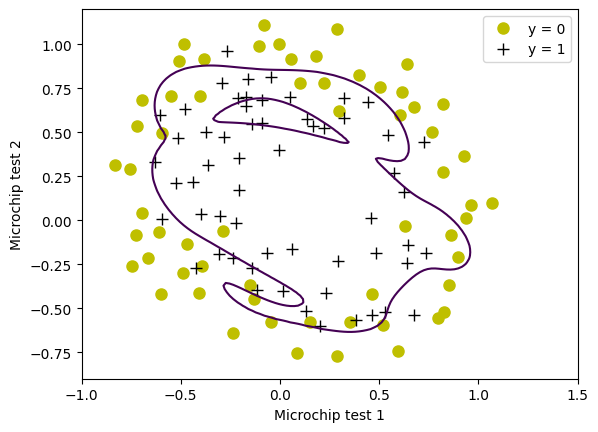

In [ ]:
plot_decision_boundary(test_1, test_2, theta, X, y)

In [ ]:
print('For a microchip with test 1 and 2 scores of 0 and 0, we predict y = 1 with a probability of',prediction(theta, 0, 0))

For a microchip with test 1 and 2 scores of 0 and 0, we predict y = 1 with a probability of 1.0


In [ ]:
print('Train Accuracy:', accuracy(theta, test_1, test_2, y, M))

Train Accuracy: 0.864406779661017


In [ ]:
lam=10
theta_0 = np.zeros(N)


In [ ]:
cost_0, _ = cost_function(theta_0, X, y, M, lam)

print('Cost at initial theta (zeros):', cost_0)

Cost at initial theta (zeros): 0.6931471805599454


In [ ]:
cost_history = []

"""This call to scipy's "minimize" is a Python version of the Octave call to "fminunc"."""
res = minimize(cost_function, theta_0, method='L-BFGS-B', args=(X, y, M, lam), jac=True)
print(res)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.616409563335955
        x: [ 3.265e-01 -8.778e-03 ... -1.223e-02 -2.724e-01]
      nit: 7
      jac: [-1.609e-04 -1.983e-04 ... -2.004e-05 -9.986e-05]
     nfev: 40
     njev: 40
 hess_inv: <28x28 LbfgsInvHessProduct with dtype=float64>


In [ ]:
theta = res['x']

print('Cost at best-fit theta:', res['fun'])

Cost at best-fit theta: 0.616409563335955


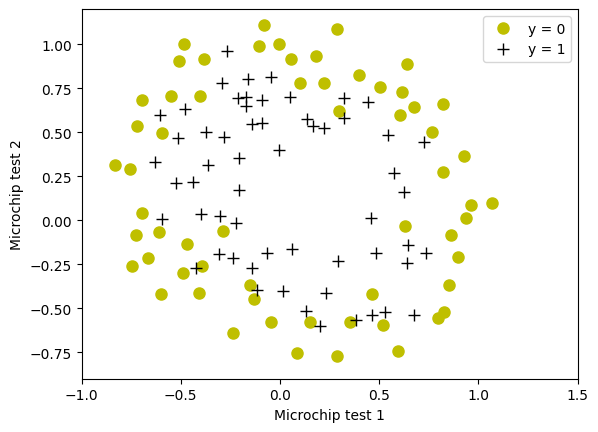

In [ ]:
plot_decision_boundary(test_1, test_2, theta, X, y)

In [ ]:
print('For a microchip with test 1 and 2 scores of 0 and 0, we predict y = 1 with a probability of',prediction(theta, 0, 0))

For a microchip with test 1 and 2 scores of 0 and 0, we predict y = 1 with a probability of 0.45672356111506063


In [ ]:
print('Train Accuracy:', accuracy(theta, test_1, test_2, y, M))

Train Accuracy: 0.5084745762711864


In [ ]:
# install the required package
!pip install scikit-learn

# Import necessary modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #random_state set for reproducibility

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000) #max_iter added as models were failing to converge in a reasonable number of iterations.
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

#the rest of the imports are added here as well


Confusion Matrix:
[[13  3]
 [ 6 14]]
F1 Score: 0.76
AUC-ROC: 0.88


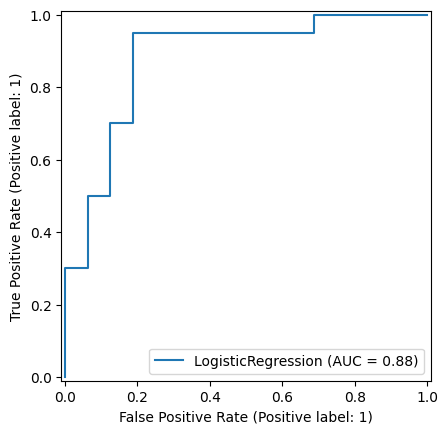

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

#code block 66
conf_matrix = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("Confusion Matrix:")
print(conf_matrix)
print(f"F1 Score: {f1:.2f}")
print(f"AUC-ROC: {roc_auc:.2f}")

# Plot ROC curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()